In [ ]:
!pip install rdkit

import rdkit
print("RDKit version:", rdkit.__version__)

from rdkit import Chem
mol = Chem.MolFromSmiles('CCO')  # ethanol
print(f"Molecule created: {Chem.MolToSmiles(mol)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 40.2 MB/s eta 0:00:00
RDKit version: 2025.09.5
Molecule created: CCO


In [ ]:
!pip install openpyxl scikit-learn pandas numpy matplotlib seaborn joblib xgboost

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

In [ ]:
# =====================================================
# STEP 1: Load Dataset
# =====================================================

DATA_PATH = "det_dataset_08-02-2022.xlsx"
df = pd.read_excel(DATA_PATH)

df = df[['SMILES', 'HOF', 'Density', 'VODexp']]
df = df.dropna().reset_index(drop=True)
df.head()

,SMILES,HOF,Density,VODexp
0,C1(=NNN=N1)[N+](=O)[O-],261.395,1.73,8.900
1,C(O[N+](=O)[O-])O[N+](=O)[O-],93.300,1.55,6.205
2,C[N+](=O)[O-],-112.968,1.13,6.350
3,CO[N+](=O)[O-],-154.000,1.21,6.750
4,C(=O)(N)N[N+](=O)[O-],-281.000,1.10,5.480


In [ ]:
# =====================================================
# STEP 2: Cleaning & Preprocessing
# =====================================================

def is_valid_smiles(smiles):
    return Chem.MolFromSmiles(smiles) is not None

df = df.dropna()
df = df[df['SMILES'].apply(is_valid_smiles)].reset_index(drop=True)

print("Cleaned data rows:", df.shape[0])


Cleaned data rows: 236


In [ ]:
# =====================================================
# STEP 3: Feature Generation
# =====================================================

morgan_gen = GetMorganGenerator(radius=2, fpSize=1024)

def oxygen_balance(mol):
    formula = Descriptors.MolWt(mol)
    nC = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'C')
    nH = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'H')
    nO = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'O')

    if formula == 0:
        return 0

    OB = (1600 * (nO - 2*nC - nH/2)) / formula
    return OB

def count_nitro_groups(mol):
    nitro = Chem.MolFromSmarts('[N+](=O)[O-]')
    return len(mol.GetSubstructMatches(nitro))

def generate_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Basic descriptors
    descriptors = [
        Descriptors.MolWt(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.MolLogP(mol),
        Descriptors.RingCount(mol)
    ]

    # Element counts
    nC = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'C')
    nH = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'H')
    nN = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'N')
    nO = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'O')

    total_atoms = mol.GetNumAtoms()
    nitrogen_ratio = nN / total_atoms if total_atoms > 0 else 0

    OB = oxygen_balance(mol)
    nitro_count = count_nitro_groups(mol)

    structural_features = [
        nC, nH, nN, nO,
        nitrogen_ratio,
        OB,
        nitro_count
    ]

    fp = np.array(morgan_gen.GetFingerprint(mol))

    return np.concatenate([descriptors, structural_features, fp])

X = np.vstack(df['SMILES'].apply(generate_features))

y_hof = df['HOF'].values
y_density = df['Density'].values
y_vod = df['VODexp'].values

print("Feature matrix shape:", X.shape)


Feature matrix shape: (236, 1037)


In [ ]:
# =====================================================
# STEP 4: Train–Test Split & Scaling
# =====================================================

X_train, X_test, y_hof_train, y_hof_test, \
y_density_train, y_density_test, \
y_vod_train, y_vod_test = train_test_split(
    X, y_hof, y_density, y_vod,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# =====================================================
# STEP 5: Model Definitions
# =====================================================

models = {
    "RF": RandomForestRegressor(random_state=42),
    "GB": GradientBoostingRegressor(random_state=42),
    "LR": LinearRegression(),
    "XGB": XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

param_grids = {
    "RF": {"n_estimators": [200], "max_depth": [None, 10]},
    "GB": {"n_estimators": [200], "learning_rate": [0.05, 0.1]},
    "LR": {},
    "XGB": {
        "n_estimators": [300],
        "max_depth": [4, 6],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8],
        "colsample_bytree": [0.8]
    }
}


In [ ]:
# =====================================================
# STEP 6: Model Training
# =====================================================

def train_models(X, y):
    trained = {}

    for name, model in models.items():
        if name == "LR":
            model.fit(X, y)
            trained[name] = model
        else:
            grid = GridSearchCV(
                model,
                param_grids[name],
                cv=5,
                scoring="neg_root_mean_squared_error",
                n_jobs=-1
            )
            grid.fit(X, y)
            trained[name] = grid.best_estimator_

    return trained

hof_models = train_models(X_train, y_hof_train)
density_models = train_models(X_train, y_density_train)
vod_models = train_models(X_train, y_vod_train)


In [ ]:
# =====================================================
# STEP 7: Model Evaluation
# =====================================================

def evaluate(models, X_test, y_test):
    scores = {}
    for name, model in models.items():
        preds = model.predict
        scores[name] = {
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "R2": r2_score(y_test, preds)
        }
    return pd.DataFrame(scores).T

hof_scores = evaluate(hof_models, X_test, y_hof_test)
density_scores = evaluate(density_models, X_test, y_density_test)
vod_scores = evaluate(vod_models, X_test, y_vod_test)

hof_scores, density_scores, vod_scores


(            MAE        RMSE        R2
 RF   224.246903  285.634457  0.652552
 GB   197.609136  259.685558  0.712814
 LR   351.960229  484.173974  0.001677
 XGB  189.637478  252.610727  0.728249,
           MAE      RMSE           R2
 RF   0.094820  0.121826     0.495963
 GB   0.089041  0.118238     0.525218
 LR   5.993553  6.097592 -1261.696235
 XGB  0.093560  0.118432     0.523654,
           MAE      RMSE        R2
 RF   0.589948  0.919336  0.185674
 GB   0.577640  0.850480  0.303087
 LR   0.871951  1.249469 -0.504184
 XGB  0.628934  0.927304  0.171496)

In [ ]:
# =====================================================
# STEP 8: Save Best Models
# =====================================================

def select_best_model(scores_df, trained_models):
    # Sort by RMSE first, then MAE
    ranked = scores_df.sort_values(by=["RMSE", "MAE"], ascending=[True, True])

    best_model_name = ranked.index[0]
    best_model = trained_models[best_model_name]

    print(f"Best model selected: {best_model_name}")
    print(ranked.loc[best_model_name])

    return best_model_name, best_model


os.makedirs("models", exist_ok=True)

best_hof_name, best_hof = select_best_model(hof_scores, hof_models)
best_density_name, best_density = select_best_model(density_scores, density_models)
best_vod_name, best_vod = select_best_model(vod_scores, vod_models)

joblib.dump(best_hof, "models/hof_model.pkl")
joblib.dump(best_density, "models/density_model.pkl")
joblib.dump(best_vod, "models/vod_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("\nFinal selected models:")
print(f"HOF     → {best_hof_name}")
print(f"Density → {best_density_name}")
print(f"VOD     → {best_vod_name}")

Best model selected: XGB
MAE     189.637478
RMSE    252.610727
R2        0.728249
Name: XGB, dtype: float64
Best model selected: GB
MAE     0.089041
RMSE    0.118238
R2      0.525218
Name: GB, dtype: float64
Best model selected: GB
MAE     0.577640
RMSE    0.850480
R2      0.303087
Name: GB, dtype: float64

Final selected models:
HOF     → XGB
Density → GB
VOD     → GB


In [ ]:
# =====================================================
# STEP 9: Screening & Normalized Ranking
# =====================================================

df['Pred_HOF'] = hof_models["XGB"].predict(scaler.transform(X))
df['Pred_Density'] = density_models["XGB"].predict(scaler.transform(X))
df['Pred_VODexp'] = vod_models["XGB"].predict(scaler.transform(X))

# Recalculate oxygen balance for rules
df['OxygenBalance'] = df['SMILES'].apply(
    lambda x: oxygen_balance(Chem.MolFromSmiles(x))
)

# Rule Check
df['HEDM_Qualified'] = (
    (df['Pred_Density'] >= 1.75) &
    (df['OxygenBalance'] > 0) &
    (df['Pred_VODexp'] >= 7000)
)

# Normalized ranking
for col in ['Pred_HOF', 'Pred_Density', 'Pred_VODexp']:
    df[col + "_norm"] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

df['Final_Score'] = (
    df['Pred_HOF_norm'] +
    df['Pred_Density_norm'] +
    df['Pred_VODexp_norm']
) / 3

ranked_df = df.sort_values(
    by=['HEDM_Qualified', 'Final_Score'],
    ascending=False
)

ranked_df.to_csv("ranked_HEDM_compounds.csv", index=False)



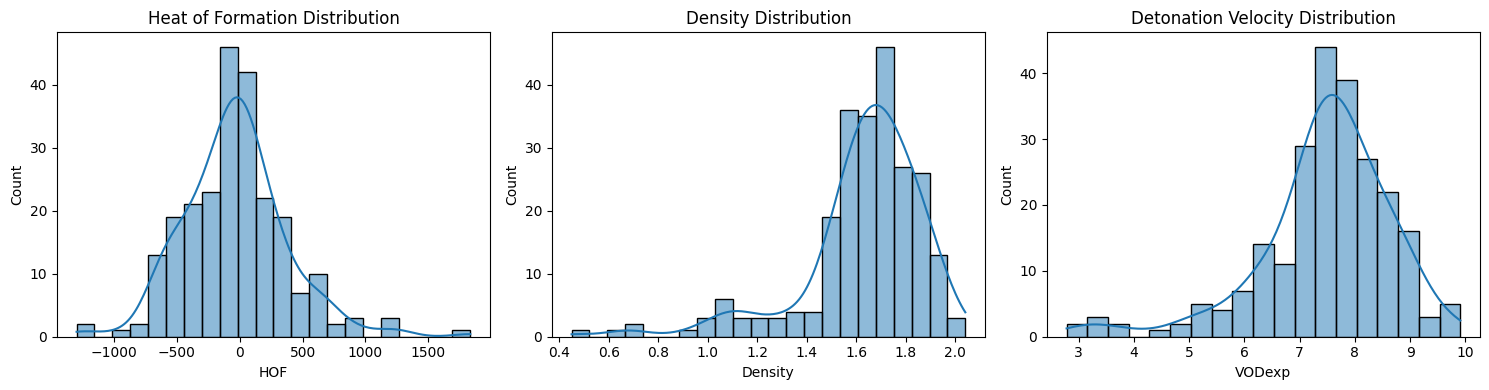

In [ ]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(df['HOF'], kde=True)
plt.title("Heat of Formation Distribution")

plt.subplot(1,3,2)
sns.histplot(df['Density'], kde=True)
plt.title("Density Distribution")

plt.subplot(1,3,3)
sns.histplot(df['VODexp'], kde=True)
plt.title("Detonation Velocity Distribution")

plt.tight_layout()
plt.show()

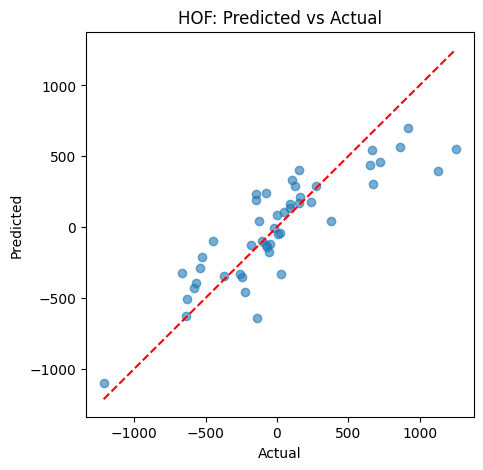

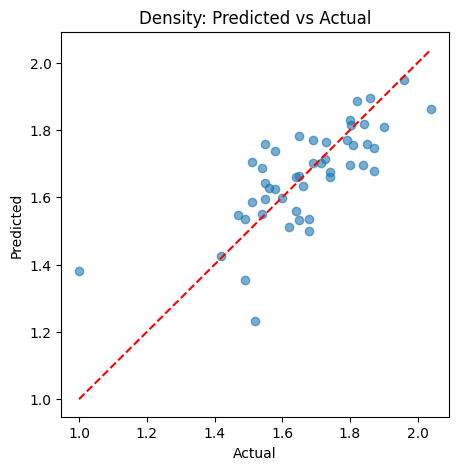

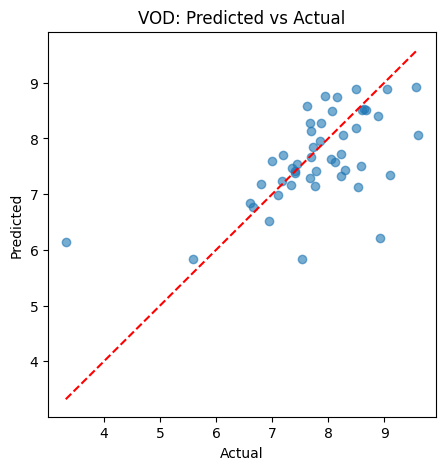

In [ ]:
def plot_predicted_vs_actual(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

# HOF
plot_predicted_vs_actual(y_hof_test, best_hof.predict(X_test),
                         "HOF: Predicted vs Actual")

# Density
plot_predicted_vs_actual(y_density_test, best_density.predict(X_test),
                         "Density: Predicted vs Actual")

# VOD
plot_predicted_vs_actual(y_vod_test, best_vod.predict(X_test),
                         "VOD: Predicted vs Actual")


In [ ]:
# =====================================================
# STEP 10: Prediction on New / Unseen Compounds
# =====================================================

def predict_unseen(smiles_list):
    feats = np.vstack([generate_features(s) for s in smiles_list])
    feats_scaled = scaler.transform(feats)

    return pd.DataFrame({
        "SMILES": smiles_list,
        "Pred_HOF": best_hof.predict(feats_scaled),
        "Pred_Density": best_density.predict(feats_scaled),
        "Pred_VODexp": best_vod.predict(feats_scaled)
    })

unseen = ["C1(=NNN=N1)[N+](=O)[O-]"]
predict_unseen(unseen)



,SMILES,Pred_HOF,Pred_Density,Pred_VODexp
0,C1(=NNN=N1)[N+](=O)[O-],248.784607,1.693083,8.725692


In [ ]:
# =====================================================
# STEP 11: Predict + Rank Compounds from Uploaded CSV
# =====================================================

New_compounds_CSV_PATH = "New_Compound_SMILES(1).csv"
unseen_df = pd.read_csv(New_compounds_CSV_PATH)

assert "SMILES" in unseen_df.columns, "CSV must contain a 'SMILES' column"

# =====================================================
# Load trained models & scaler
# =====================================================

best_hof = joblib.load("models/hof_model.pkl")
best_density = joblib.load("models/density_model.pkl")
best_vod = joblib.load("models/vod_model.pkl")
scaler = joblib.load("models/scaler.pkl")

In [ ]:
# =====================================================
# Feature generation
# =====================================================
morgan_gen = GetMorganGenerator(radius=2, fpSize=1024)

def oxygen_balance(mol):
    mol_wt = Descriptors.MolWt(mol)
    nC = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'C')
    nH = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'H')
    nO = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'O')

    if mol_wt == 0:
        return 0

    OB = (1600 * (nO - 2*nC - nH/2)) / mol_wt
    return OB

def count_nitro_groups(mol):
    nitro = Chem.MolFromSmarts('[N+](=O)[O-]')
    return len(mol.GetSubstructMatches(nitro))

def generate_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Basic descriptors
    descriptors = [
        Descriptors.MolWt(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.MolLogP(mol),
        Descriptors.RingCount(mol)
    ]

    # Element counts
    nC = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'C')
    nH = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'H')
    nN = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'N')
    nO = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'O')

    total_atoms = mol.GetNumAtoms()
    nitrogen_ratio = nN / total_atoms if total_atoms > 0 else 0

    OB = oxygen_balance(mol)
    nitro_count = count_nitro_groups(mol)

    structural_features = [
        nC, nH, nN, nO,
        nitrogen_ratio,
        OB,
        nitro_count
    ]

    fp = np.array(morgan_gen.GetFingerprint(mol))

    return np.concatenate([descriptors, structural_features, fp])

features = []
valid_indices = []

for idx, smiles in enumerate(unseen_df["SMILES"]):
    feat = generate_features(smiles)
    if feat is not None:
        features.append(feat)
        valid_indices.append(idx)

features = np.vstack(features)
features_scaled = scaler.transform(features)

unseen_df = unseen_df.iloc[valid_indices].reset_index(drop=True)

In [ ]:
# =====================================================
# Predictions
# =====================================================
unseen_df["Pred_HOF"] = best_hof.predict(features_scaled)
unseen_df["Pred_Density"] = best_density.predict(features_scaled)
unseen_df["Pred_VODexp"] = best_vod.predict(features_scaled)


unseen_df["OxygenBalance"] = unseen_df["SMILES"].apply(
    lambda x: oxygen_balance(Chem.MolFromSmiles(x))
)

def contains_CHNO(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    atoms = set(a.GetSymbol() for a in mol.GetAtoms())
    return all(x in atoms for x in ["C", "H", "N", "O"])

unseen_df["HEDM_Qualified"] = (
    (unseen_df["Pred_Density"] >= 1.60) &
    (unseen_df["OxygenBalance"] > 0) &
    (unseen_df["Pred_VODexp"] >= 7)&
    (unseen_df["SMILES"].apply(contains_CHNO))
)

'''
Density unit  g/cm^3
OxygenBalance unit %
VODexp unit  km/s
'''
# =====================================================
# Min–Max Normalization (same as Step 9)
# =====================================================

for col in ["Pred_HOF", "Pred_Density", "Pred_VODexp"]:
    unseen_df[col + "_norm"] = (
        (unseen_df[col] - unseen_df[col].min()) /
        (unseen_df[col].max() - unseen_df[col].min())
    )

unseen_df["Final_Score"] = (
    unseen_df["Pred_HOF_norm"] +
    unseen_df["Pred_Density_norm"] +
    unseen_df["Pred_VODexp_norm"]
) / 3


# =====================================================
# Ranking
# =====================================================

ranked_unseen_df = unseen_df.sort_values(
    by=["HEDM_Qualified", "Final_Score"],
    ascending=False
)

OUTPUT_PATH = "ranked_unseen_HEDM_compounds.csv"
ranked_unseen_df.to_csv(OUTPUT_PATH, index=True, index_label="Original_Index")

print("✅ Ranked file saved as:", OUTPUT_PATH)
ranked_unseen_df.head(30)

✅ Ranked file saved as: ranked_unseen_HEDM_compounds.csv


,SMILES,Pred_HOF,Pred_Density,Pred_VODexp,OxygenBalance,HEDM_Qualified,Pred_HOF_norm,Pred_Density_norm,Pred_VODexp_norm,Final_Score
30,O=[N+](ON1CN(O[N+]([O-])=O)CN(O[N+]([O-])=O)C1...,-171.324814,1.828918,8.767702,17.770275,True,1.000000,1.000000,1.000000,1.000000
0,O=[N+](OCC(CO[N+]([O-])=O)(CO[N+]([O-])=O)N=NC...,-172.313919,1.667709,8.362981,6.296461,True,0.998628,0.696143,0.860725,0.851832
24,ON=NC(CO[N+]([O-])=O)(CO[N+]([O-])=O)CO[N+]([O...,-250.612244,1.693774,8.306876,11.223148,True,0.890008,0.745273,0.841417,0.825566
21,OC(O)(O)N=NC(O[N+]([O-])=O)(O[N+]([O-])=O)O[N+...,-196.802979,1.754471,7.486387,44.280085,True,0.964655,0.859677,0.559065,0.794466
15,OC(CO[N+]([O-])=O)(CO[N+]([O-])=O)N=NC(O)(CO[N...,-457.805298,1.701198,8.362209,8.201469,True,0.602577,0.759265,0.860459,0.740767
22,OC(O)(O)N=CC(O[N+]([O-])=O)(O[N+]([O-])=O)O[N+...,-318.354340,1.739495,7.023006,33.323961,True,0.796032,0.831449,0.399603,0.675694
18,OC(O)(O)N=NC(O)(O)O,-247.837372,1.630317,7.096658,20.768702,True,0.893857,0.625664,0.424948,0.648156
23,OC(O)(O)C=CC(O[N+]([O-])=O)(O[N+]([O-])=O)O[N+...,-647.306824,1.715961,7.567362,22.292428,True,0.339690,0.787090,0.586930,0.571237
12,OCC(CO[N+]([O-])=O)(CO[N+]([O-])=O)N=NC(CO[N+]...,-402.984436,1.648334,8.362209,0.000000,False,0.678628,0.659623,0.860459,0.732903
16,OC(CO[N+]([O-])=O)(CO[N+]([O-])=O)N=CC(O)(CO[N...,-531.365845,1.731499,8.264642,0.000000,False,0.500530,0.816378,0.826883,0.714597
